## Source

Estimates are derived from the Global Forest Watch website (conversion emissions) for Uganda by combining estimates of total above-ground biomass C stocks in forests with total areas to generate an estimate of a per-unit factor to directly estimate conversion emissions, then comparing this with conversion emissions accounted for in the inventories. 2015 Shows _negative_ conversion emissions from converting forests to cropland (?), so its value is instead determined as a mean of values from 2016-2019.


In [1]:
import numpy as np
import pandas as pd
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import sys
dirs_add = [
    "/Users/usuario/git/sisepuede",
    str(pathlib.Path(os.getcwd()).parents[0])
]
for dir_add in dirs_add:
    if dir_add not in sys.path:
        sys.path.append(dir_add)
    
import sisepuede.utilities._toolbox as sf
import utils.common_data_needs as cdn
import utils.manual_adjustments as uma

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling NemoMod...
Info Given NemoMod was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1503.9 ms  ? NemoMod
[ Info: Precompiling NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72] 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing NemoMod [a3c327a0-d2f0-11e8-37fd-d12fd35c3c72].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.


In [50]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:

# get SISEPUEDE elements
dict_ssp = cdn._setup_sisepuede_elements()
examples = cdn._SISEPUEDE_EXAMPLES
struct = cdn._SISEPUEDE_FILE_STRUCTURE

# shortcuts
matt = dict_ssp.get("model_attributes", )
models = dict_ssp.get("models", )
regions = dict_ssp.get("regions", )
time_periods = dict_ssp.get("time_periods", )

# setup region
_REGION_NAME = "uganda"
_REGION_ISO = regions.return_region_or_iso(_REGION_NAME, return_type = "iso")


In [8]:
# Set up paths
CURRENT_DIR_PATH = pathlib.Path(os.path.abspath("."))
OUTPUT_DATA_DIR_PATH = CURRENT_DIR_PATH.joinpath("output_data")
INPUT_DATA_DIR_PATH = CURRENT_DIR_PATH.joinpath("input_data")

In [9]:

modvar_frst_frac = matt.get_variable(models.model_enercons.modvar_frst_conversion_frac_for_fuelwood, )
field_frst_frac = modvar_frst_frac.fields[0]

In [20]:

path_file = INPUT_DATA_DIR_PATH.joinpath("estimating_fraction_of_conversion_available_for_biomass.xlsx")
df = pd.read_excel(
    path_file,
    skiprows = 3,
)

field_frac = "est frac available for bmass"
field_yr = "loss by year"
df = (
    df
    .get([field_yr, field_frac])
    .rename(
        columns = {
            field_yr: time_periods.field_year,
            field_frac: field_frst_frac,
        }
    )
)

val_mean = np.mean(
    df[
        df[time_periods.field_year] >= 2015
    ][field_frst_frac]
    .dropna(), 
)
df[field_frst_frac] = (
    df[field_frst_frac]
    .fillna(
        val_mean,
    )
)




##  Build a smoother ramp down
- reduces conversion available for biomass
- reduced biomass demand should reduce deforestation demands
- this is an accounting issue; it also represents a shift away from forestry-driven biomass extraction to biomass from shrublands, twigs, sticks, etc.

In [25]:

#
#    
#
_YEAR_0 = time_periods.all_years[0]
_YEAR_1 = 2100
n = _YEAR_1 - _YEAR_0 + 1

# get beginning of shift
tp_0_drop = time_periods.year_to_tp(2026)

# build a smooth vector to shift
vec = sf.ramp_vector(
    n,
    alpha_logistic = 1,
    r_0 = tp_0_drop,
    r_1 = uma._BIOMASS_SHIFT_IMPLEMENTATION_TP_END,
    window_logistic = (-5, 5, )
)

# update values and set as a dataframe
v_end = 0.25
diff = val_mean - v_end
vec_new = v_end + (1 - vec)*diff

df_ramp = pd.DataFrame(
    {
        time_periods.field_year: range(_YEAR_0, _YEAR_1 + 1),
        field_frst_frac: vec_new,
    }
)




##  Combine and merge

In [26]:
field_year = time_periods.field_year
df_fracs = pd.concat(
    [
        df,
        df_ramp[
            ~df_ramp[field_year].isin(df[field_year].to_numpy())
        ]
        .reset_index(drop = True,)
    ]
)

df_fracs = (
    pd.merge(
        pd.DataFrame(
            {
                field_year: range(_YEAR_0, _YEAR_1 + 1),
            }
        ),
        df_fracs,
        how = "left",
    )
    .interpolate()
    .ffill()
)

<Axes: xlabel='year'>

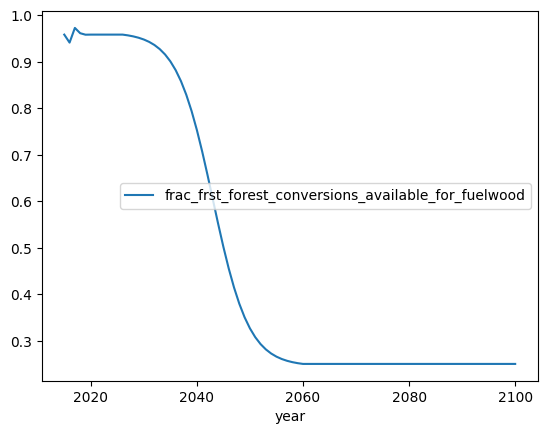

In [27]:

df_fracs.plot(x = "year", )


In [44]:
cdn.file_name_from_variable(modvar_frst_frac, )

'FRACTION_OF_FOREST_CONVERSIONS_AVAILABLE_FOR_FUELWOOD.csv'

In [28]:
fn_write = cdn.file_name_from_variable(modvar_frst_frac, )
sf._write_csv(
    df_fracs,
    cdn._PATH_OUTPUTS.joinpath(fn_write),
)


True